In [1]:
!pip install -q transformers==4.41.2 sentencepiece==0.2.0 evaluate sacrebleu rouge-score accelerate -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 66.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 85.5 MB/s eta 0:00:00:00:01


In [2]:
import os, json, time, re
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
import matplotlib.pyplot as plt
from difflib import SequenceMatcher
from collections import Counter
import joblib

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed_all(SEED)


PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
# Dataset yolunu bul
for d, _, files in os.walk('/kaggle/input'):
    if any('yenipoz_test.csv' in f for f in files):
        DATASET_PATH = d
        print(f"Dataset bulundu: {DATASET_PATH}")
        break

# V3 verileri
train_v2_only = pd.read_csv(f'{DATASET_PATH}/yumusatma_train_FINAL_v2.csv')
val_v2_only = pd.read_csv(f'{DATASET_PATH}/yumusatma_val_FINAL_v2.csv')
eval_df = pd.read_csv(f'{DATASET_PATH}/yumusatma_eval_FINAL.csv')

# Yenipoz eğitim augmentation (393 çift) - DATA LEAKAGE ÇÖZÜMÜ
yenipoz_aug = pd.read_csv(f'{DATASET_PATH}/yenipoz_train_aug.csv')

# 70/30 stratified split: 275 train + 118 test
from sklearn.model_selection import train_test_split
yenipoz_train_part, yenipoz_test_part = train_test_split(
    yenipoz_aug, test_size=0.30, random_state=42,
    stratify=yenipoz_aug['provider']
)
print(f"Yenipoz: {len(yenipoz_train_part)} train + {len(yenipoz_test_part)} test (held-out)")

# Test setini ayrı sakla
yenipoz_held_out_test = yenipoz_test_part.copy()
yenipoz_held_out_test.to_csv('/kaggle/working/yenipoz_test_heldout.csv', index=False)

# Train için 80/10 yenipoz_train_part split (val'a da pay ver)
yp_train, yp_val = train_test_split(
    yenipoz_train_part, test_size=0.12, random_state=42,
    stratify=yenipoz_train_part['provider']
)

# V2 + yenipoz_train birleştir
train_df = pd.concat([train_v2_only, yp_train], ignore_index=True)
val_df = pd.concat([val_v2_only, yp_val], ignore_index=True)

# Dedup
train_df['key'] = train_df['input'].astype(str) + '||' + train_df['target'].astype(str)
train_df = train_df.drop_duplicates(subset='key').drop(columns='key').reset_index(drop=True)

print(f"\nFINAL Train: {len(train_df)}")
print(f"FINAL Val: {len(val_df)}")
print(f"Eval (Altın standart): {len(eval_df)}")
print(f"Held-out yenipoz test: {len(yenipoz_held_out_test)}")
print(f"\n*** Held-out test seti EĞİTİMDE GÖRÜLMEDİ ***")


Dataset bulundu: /kaggle/input/datasets/huseyinkaplan0/tez-spam-emails-tr
Yenipoz: 275 train + 118 test (held-out)

FINAL Train: 1235
FINAL Val: 144
Eval (Altın standart): 31
Held-out yenipoz test: 118

*** Held-out test seti EĞİTİMDE GÖRÜLMEDİ ***


In [4]:
MODEL_NAME = "ozcangundes/mt5-small-turkish-summarization"
MAX_INPUT_LEN = 256
MAX_TARGET_LEN = 256

print(f"Model yükleniyor: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
model = model.to(DEVICE)
print(f"Parametre sayısı: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")


Model yükleniyor: ozcangundes/mt5-small-turkish-summarization


tokenizer_config.json:   0%|          | 0.00/388 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:560: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Parametre sayısı: 300.2M


In [5]:
class YumusatmaDataset(Dataset):
    def __init__(self, df, tokenizer, max_input=256, max_target=256, prefix="yumusat: "):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_input = max_input
        self.max_target = max_target
        self.prefix = prefix
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        source = self.prefix + str(row['input'])
        target = str(row['target'])
        source_enc = self.tokenizer(source, max_length=self.max_input,
            padding='max_length', truncation=True, return_tensors='pt')
        target_enc = self.tokenizer(target, max_length=self.max_target,
            padding='max_length', truncation=True, return_tensors='pt')
        labels = target_enc['input_ids'].squeeze()
        labels[labels == self.tokenizer.pad_token_id] = -100
        return {
            'input_ids': source_enc['input_ids'].squeeze(),
            'attention_mask': source_enc['attention_mask'].squeeze(),
            'labels': labels
        }

train_ds = YumusatmaDataset(train_df, tokenizer, MAX_INPUT_LEN, MAX_TARGET_LEN)
val_ds = YumusatmaDataset(val_df, tokenizer, MAX_INPUT_LEN, MAX_TARGET_LEN)

BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 4
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batch: {len(train_loader)}, Val batch: {len(val_loader)}")


Train batch: 618, Val batch: 72


In [6]:
EPOCHS = 7
LEARNING_RATE = 5e-4
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
GRADIENT_CLIP = 1.0

total_steps = (len(train_loader) // GRAD_ACCUM_STEPS) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

print(f"Toplam step: {total_steps}, Warmup: {warmup_steps}")


Toplam step: 1078, Warmup: 107


In [7]:
os.makedirs('/kaggle/working/checkpoints', exist_ok=True)
os.makedirs('/kaggle/working/figures', exist_ok=True)
torch.cuda.empty_cache()

train_losses = []
val_losses = []
nan_counter = 0
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    print(f"\n{'='*60}\nEPOCH {epoch+1}/{EPOCHS}\n{'='*60}")
    model.train()
    epoch_loss = 0
    valid_batches = 0
    t0 = time.time()
    optimizer.zero_grad()
    for step, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss / GRAD_ACCUM_STEPS
        if torch.isnan(loss) or torch.isinf(loss):
            nan_counter += 1
            optimizer.zero_grad()
            continue
        loss.backward()
        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
        epoch_loss += loss.item() * GRAD_ACCUM_STEPS
        valid_batches += 1
        if step % 50 == 0:
            print(f"  Step {step}/{len(train_loader)} - Loss: {loss.item()*GRAD_ACCUM_STEPS:.4f}")
    avg_train_loss = epoch_loss / max(valid_batches, 1)
    train_losses.append(avg_train_loss)
    train_time = (time.time() - t0) / 60
    model.eval()
    val_loss_sum = 0; val_valid = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            if not (torch.isnan(outputs.loss) or torch.isinf(outputs.loss)):
                val_loss_sum += outputs.loss.item()
                val_valid += 1
    avg_val_loss = val_loss_sum / max(val_valid, 1)
    val_losses.append(avg_val_loss)
    print(f"\n  Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f} | Süre: {train_time:.1f}dk")
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        model.save_pretrained('/kaggle/working/checkpoints/best')
        tokenizer.save_pretrained('/kaggle/working/checkpoints/best')
        print(f"    ✓ Best kaydedildi (val_loss={avg_val_loss:.4f})")
    torch.cuda.empty_cache()

print(f"\nEĞİTİM TAMAMLANDI. En iyi val_loss: {best_val_loss:.4f}, NaN: {nan_counter}")



EPOCH 1/7
  Step 0/618 - Loss: 4.1073
  Step 50/618 - Loss: 4.6876
  Step 100/618 - Loss: 3.2609
  Step 150/618 - Loss: 2.0193
  Step 200/618 - Loss: 4.0873
  Step 250/618 - Loss: 3.5613
  Step 300/618 - Loss: 3.5710
  Step 350/618 - Loss: 2.7879
  Step 400/618 - Loss: 3.0183
  Step 450/618 - Loss: 2.6375
  Step 500/618 - Loss: 1.4838
  Step 550/618 - Loss: 1.5739
  Step 600/618 - Loss: 2.3875

  Train: 3.1273 | Val: 2.0950 | Süre: 3.4dk
    ✓ Best kaydedildi (val_loss=2.0950)

EPOCH 2/7
  Step 0/618 - Loss: 2.6629
  Step 50/618 - Loss: 2.6706
  Step 100/618 - Loss: 1.7017
  Step 150/618 - Loss: 1.0942
  Step 200/618 - Loss: 2.9674
  Step 250/618 - Loss: 3.4952
  Step 300/618 - Loss: 2.1410
  Step 350/618 - Loss: 2.3325
  Step 400/618 - Loss: 1.5754
  Step 450/618 - Loss: 1.9663
  Step 500/618 - Loss: 2.4940
  Step 550/618 - Loss: 1.7375
  Step 600/618 - Loss: 2.9005

  Train: 2.3099 | Val: 1.8458 | Süre: 3.5dk
    ✓ Best kaydedildi (val_loss=1.8458)

EPOCH 3/7
  Step 0/618 - Loss: 2.

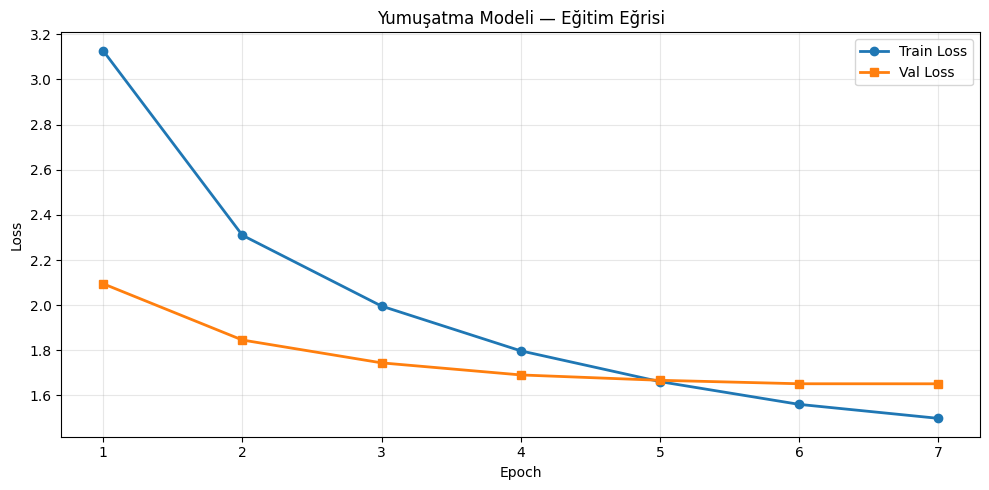

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
epochs_x = range(1, len(train_losses) + 1)
ax.plot(epochs_x, train_losses, 'o-', label='Train Loss', linewidth=2)
ax.plot(epochs_x, val_losses, 's-', label='Val Loss', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Yumuşatma Modeli — Eğitim Eğrisi')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/figures/training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

pd.DataFrame({'epoch': list(epochs_x), 'train_loss': train_losses,
    'val_loss': val_losses}).to_csv('/kaggle/working/training_history.csv', index=False)


In [9]:
print("En iyi model yükleniyor...")
model = AutoModelForSeq2SeqLM.from_pretrained('/kaggle/working/checkpoints/best').to(DEVICE)
tokenizer = AutoTokenizer.from_pretrained('/kaggle/working/checkpoints/best')
model.eval()

def yumusat(text, num_beams=4, max_length=256):
    input_text = "yumusat: " + str(text)
    inputs = tokenizer(input_text, return_tensors='pt',
        max_length=MAX_INPUT_LEN, truncation=True).to(DEVICE)
    with torch.no_grad():
        outputs = model.generate(
            inputs['input_ids'], attention_mask=inputs['attention_mask'],
            max_length=max_length, num_beams=num_beams,
            no_repeat_ngram_size=3, early_stopping=True, length_penalty=1.0
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

predictions = []
for i, row in eval_df.iterrows():
    pred = yumusat(row['input'])
    predictions.append({'input': row['input'][:200], 'gold': row['target'][:200], 'prediction': pred[:200]})
    if i < 5:
        print(f"\n--- {i+1} ---")
        print(f"GİRDİ:    {row['input'][:200]}")
        print(f"ALTIN:    {row['target'][:200]}")
        print(f"TAHMİN:   {pred[:200]}")

pred_df = pd.DataFrame(predictions)
pred_df.to_csv('/kaggle/working/eval_predictions.csv', index=False)


En iyi model yükleniyor...


You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:560: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(



--- 1 ---
GİRDİ:    Süvari'de İndirim Bayramı,Tişört 9,90TL,Gömlek 19,90 TL,Pantolon 29,90 TL,Yeni Sezon Takım 249,90 TL.İptal İçin SUVARI Yaz 3347'e Gönder.Mersis:0214042424000014
ALTIN:    Süvari'de indirim şenliği başladı! Tişörtten pantolona, yeni sezon takımlara kadar pek çok üründe harika fiyatlar sizi bekliyor. Bu fırsatları kaçırmamak için hemen mağazalarımıza uğrayın.
TAHMİN:   Süvari'de İndirim Bayramı kapsamında Tişört 9,90 TL, gömlek 19,90 TL ve yeni sezon takım 249,90 TL fiyatla satışa sunulmuştur. İptal için SUVARI yazıp 3347'e gönderebilirsiniz. Mersis: 02142424000014

--- 2 ---
GİRDİ:    %70 NET INDIRIM basladi! Yeni yil hediyelerinizi birlikte secmek icin sizi KIGILI magazalarimiza bekliyoruz. Mutlu Yillar.
ALTIN:    Kığılı mağazalarında seçili ürünlerde %70 oranında fiyat avantajı dönemi başlamıştır. Yeni yıl alışverişleriniz için mağazalarımızı ziyaret edebilirsiniz. İyi seneler dileriz.
TAHMİN:   KIGILI mağazalarında %70 net indirim kampanyası başlamıştır. Yeni yıl

In [10]:
import evaluate
bleu_metric = evaluate.load("sacrebleu")
rouge_metric = evaluate.load("rouge")

preds_text = [p['prediction'] for p in predictions]
refs_text = [[p['gold']] for p in predictions]

bleu_result = bleu_metric.compute(predictions=preds_text, references=refs_text)
rouge_refs = [p['gold'] for p in predictions]
rouge_result = rouge_metric.compute(predictions=preds_text, references=rouge_refs)

print(f"BLEU:    {bleu_result['score']:.2f}")
print(f"ROUGE-1: {rouge_result['rouge1']*100:.2f}")
print(f"ROUGE-2: {rouge_result['rouge2']*100:.2f}")
print(f"ROUGE-L: {rouge_result['rougeL']*100:.2f}")


2026-05-17 16:47:04.744638: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779036424.973392      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779036425.034108      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779036425.543591      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779036425.543632      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779036425.543635      57 computation_placer.cc:177] computation placer alr

BLEU:    4.22
ROUGE-1: 28.40
ROUGE-2: 11.21
ROUGE-L: 23.59


In [11]:
from sklearn.linear_model import LogisticRegression

spam_train_df = pd.read_csv(f'{DATASET_PATH}/spam_train.csv')
spam_test_df = pd.read_csv(f'{DATASET_PATH}/spam_test.csv')

def clean_text(t):
    t = str(t).lower()
    t = re.sub(r'http[s]?://\S+', ' URL ', t)
    t = re.sub(r'\b\d+\b', ' NUM ', t)
    t = re.sub(r'[^\wçğıöşüÇĞİÖŞÜ\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

spam_clf_svm = joblib.load(f'{DATASET_PATH}/spam_classifier.pkl')
vectorizer = joblib.load(f'{DATASET_PATH}/tfidf_vectorizer.pkl')

spam_train_df['clean'] = spam_train_df['text'].apply(clean_text)
y_train_spam = (spam_train_df['label'] == 'spam').astype(int)
X_train_spam = vectorizer.transform(spam_train_df['clean'])

spam_clf_lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
spam_clf_lr.fit(X_train_spam, y_train_spam)
print("LR modeli eğitildi")

def spam_score_svm(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    return float(spam_clf_svm.predict_proba(vec)[0][1])

def spam_score_lr(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    return float(spam_clf_lr.predict_proba(vec)[0][1])


LR modeli eğitildi


In [12]:
COMMON_TR = set("""
ve veya ile ama fakat ancak çünkü için bu şu o bir bu da de mi
ben sen biz siz onlar var yok olmak etmek demek
sayın değerli müşteri kullanıcı hocam saygı saygıyla
merhaba selam günaydın hoş tebrikler teşekkür
bilgi rica detay detaylı için adres tarih zaman
sunulmaktadır uygulanmaktadır gerçekleştirilmektedir
edebilir bulabilir bulunmaktadır
""".lower().split())

def extract_proper_nouns(text):
    text = str(text)
    candidates = re.findall(r'\b[A-ZÇĞİÖŞÜ][\w&]{2,}\b', text)
    proper = [c for c in candidates if c.lower() not in COMMON_TR]
    full_caps = re.findall(r'\b[A-ZÇĞİÖŞÜ&]{3,}\b', text)
    proper.extend(full_caps)
    return list(set(proper))

def extract_urls(text):
    text = str(text)
    urls = re.findall(r'(?:https?://|www\.)\S+', text)
    domains = re.findall(r'\b[\w-]+\.(?:com|tr|net|org|com\.tr|gov\.tr|edu\.tr)(?:/\S*)?', text)
    return list(set(urls + domains))

def extract_numbers(text):
    return list(set(re.findall(r'\b\d{2,}(?:[.,]\d+)?\b', str(text))))

def quality_check(input_text, output_text):
    issues = []
    if not output_text or len(output_text.strip()) < 20:
        return False, ["cikti_cok_kisa"]
    words = output_text.split()
    if len(words) > 5:
        repeats = Counter(words)
        for w, c in repeats.items():
            if c >= 4 and w.lower() not in COMMON_TR and len(w) > 3:
                issues.append(f"tekrar:{w}")
    inp_proper = set(p.lower() for p in extract_proper_nouns(input_text))
    out_proper = set(p.lower() for p in extract_proper_nouns(output_text))
    out_text_lower = output_text.lower()
    truly_lost = [b for b in (inp_proper - out_proper) if b not in out_text_lower]
    if truly_lost and len(truly_lost) >= 2:
        issues.append(f"marka_kaybi:{truly_lost[:3]}")
    inp_urls = set(extract_urls(input_text))
    out_urls = set(extract_urls(output_text))
    if inp_urls and not (inp_urls & out_urls):
        issues.append(f"url_kaybi")
    if len(output_text) < len(input_text) * 0.4:
        issues.append("cikti_cok_kisaldi")
    return len(issues) == 0, issues

def restore_critical_info(input_text, output_text):
    inp_urls = extract_urls(input_text)
    out_text = output_text
    for url in inp_urls:
        if url not in out_text and url.lower() not in out_text.lower():
            out_text = out_text.rstrip('.!? ')
            if not out_text.endswith('.'):
                out_text += '.'
            out_text += f' Detaylar için: {url}'
            break
    return out_text

print("Post-processing fonksiyonları hazır")


Post-processing fonksiyonları hazır


In [13]:
KNOWN_BRANDS = {
    'KIGILI', 'Kığılı', 'Süvari', 'SUVARI', 'Altinyildiz', 'ALTINYILDIZ',
    'Vestel', 'Arçelik', 'Beko', 'Karaca', 'Paşabahçe', 'LCW', 'LC Waikiki',
    'Boyner', 'YKM', 'Koton', 'Mavi', 'Defacto', 'DeFacto',
    'Migros', 'CarrefourSA', 'BIM', 'A101', 'Şok',
    'Turkcell', 'Vodafone', 'Türk Telekom', 'TTNET',
    'Garanti', 'Akbank', 'İş Bankası', 'Yapı Kredi', 'Halkbank', 'Ziraat',
    'Worldpuan', 'Bonus', 'Maximum', 'Paraf', 'Axess', 'CardFinans',
    'Hepsiburada', 'Trendyol', 'GittiGidiyor', 'N11', 'Çiçeksepeti',
    'Darüşşafaka', 'TEMA', 'TEV', 'AKUT',
    'ENUYGUN', 'EnUygun', 'Enuygun', 'Obilet', 'Tatilbudur',
    'Bilyoner', 'Spor Toto', 'Milli Piyango',
    'Dyson', 'Apple', 'Samsung', 'Huawei', 'Xiaomi', 'Nokia', 'Sony',
    'Microsoft', 'Google', 'Facebook', 'Twitter', 'Instagram', 'YouTube',
    'WhatsApp', 'Telegram', 'TikTok', 'LinkedIn',
    'Amazon', 'Netflix', 'Spotify', 'Disney',
    'Bybit', 'Binance', 'Coinbase', 'BscScan',
    'Hotmail', 'Gmail', 'Outlook', 'Yahoo',
    'Windows', 'Android', 'iOS', 'iPhone', 'iPad',
    'Aksa', 'Bosch', 'Siemens', 'Philips', 'LG',
    'Mercedes', 'BMW', 'Audi', 'Toyota', 'Honda', 'Ford', 'Renault', 'Fiat',
    'Nike', 'Adidas', 'Puma', 'Reebok', 'Mersis',
    'Gelir İdaresi Başkanlığı', 'GİB', 'SGK', 'MEB', 'YÖK',
    'Süleyman Demirel Üniversitesi', 'Siirt Üniversitesi',
    'Mart', 'Nisan', 'Mayıs', 'Haziran', 'Temmuz', 'Ağustos',
    'Eylül', 'Ekim', 'Kasım', 'Aralık', 'Ocak', 'Şubat',
    'İstanbul', 'Ankara', 'İzmir', 'Bursa', 'Antalya', 'Adana',
    'Konya', 'Gaziantep', 'Kayseri', 'Balıkesir', 'Mersin',
    'Diyarbakır', 'Eskişehir', 'Trabzon', 'Samsun', 'Isparta',
    'Vatan', 'Lenovo', 'Gratis', 'Starbucks', 'QNB', 'Masterpass',
    'Allianz', 'AXA', 'Anadolu Sigorta', 'Mapfre',
    'PTT', 'Yurtiçi Kargo', 'Aras Kargo', 'MNG Kargo', 'Sürat Kargo',
    'Hepsijet', 'UPS', 'DHL', 'FedEx',
    'Yemeksepeti', 'Getir', 'BiTaksi', 'Uber',
}
KNOWN_BRANDS_LOWER = {b.lower(): b for b in KNOWN_BRANDS}

def find_brands_in_text(text):
    text_lower = str(text).lower()
    found = {}
    for brand_lower, brand_orig in KNOWN_BRANDS_LOWER.items():
        pattern = r'\b' + re.escape(brand_lower) + r'\b'
        if re.search(pattern, text_lower):
            found[brand_lower] = brand_orig
    return found

def restore_brands(input_text, output_text):
    fixed = output_text
    inp_lower = str(input_text).lower()
    if 'kigili' in inp_lower or 'kığılı' in inp_lower:
        fixed = re.sub(r'\bkişisel\b', 'KIGILI', fixed, flags=re.IGNORECASE)
        fixed = re.sub(r'\bKişisel\b', 'KIGILI', fixed)
    if 'aksa' in inp_lower:
        fixed = re.sub(r'^Sayın Enerjiniz[,.]?\s*', '', fixed)
        fixed = re.sub(r'eğlenceliz', 'eğlenceniz', fixed)
    inp_brands = find_brands_in_text(input_text)
    out_brands = find_brands_in_text(fixed)
    lost = set(inp_brands.keys()) - set(out_brands.keys())
    for inp_brand_lower in lost:
        original_brand = inp_brands[inp_brand_lower]
        if original_brand.lower() not in fixed.lower():
            fixed = fixed.rstrip('.!? ')
            fixed += f". {original_brand} markası ile ilgili detaylar için iletişim kanallarını inceleyebilirsiniz."
    return fixed

def yumusat_v3(text, num_beams=8, max_length=256):
    input_text = "yumusat: " + str(text)
    inputs = tokenizer(input_text, return_tensors='pt',
        max_length=MAX_INPUT_LEN, truncation=True).to(DEVICE)
    with torch.no_grad():
        outputs = model.generate(
            inputs['input_ids'], attention_mask=inputs['attention_mask'],
            max_length=max_length, num_beams=num_beams,
            no_repeat_ngram_size=3, repetition_penalty=1.3,
            length_penalty=1.2, early_stopping=True, do_sample=False,
        )
    raw_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
    cleaned = restore_critical_info(text, raw_output)
    cleaned = restore_brands(text, cleaned)
    inp_urls = extract_urls(text)
    for url in inp_urls:
        domain_short = re.sub(r'\.tr$', '', url)
        if domain_short != url and domain_short in cleaned and url not in cleaned:
            cleaned = cleaned.replace(domain_short, url)
    is_ok, issues = quality_check(text, cleaned)
    return {'original': text, 'softened': cleaned, 'raw_output': raw_output,
        'issues': issues, 'acceptable': is_ok}

# Doğrulama
print("yumusat_v3:", 'yumusat_v3' in dir())
print("Test:", yumusat_v3("KIGILI BUYUK INDIRIM!! HEMEN ALIN")['softened'])


yumusat_v3: True
Test: Sayın müşterimiz, KIGILI üründe geçerli olmak üzere indirim uygulanmaktadır. Kampanyaya katılmak için iletişime geçmenizi rica ederiz.


In [14]:
test_cases = [
    "%70 NET INDIRIM basladi! Yeni yil hediyelerinizi birlikte secmek icin sizi KIGILI magazalarimiza bekliyoruz. Mutlu Yillar.",
    "BEDAVA!!! HEMEN TIKLA www.kazandiniz.com %100 KAZANDIN ŞIMDI AL ÖZEL FIRSAT ACIL!!!",
    "Dyson Kablosuz Süpürgeler dyson.com.tr dyson.com.tr Dyson Kablosuz Süpürgeler Kablosuz, zahmetsiz temizlik, hijyenik hazne boşaltma sistemi ve HEPA filtre.",
    "Süvari'de İndirim Bayramı,Tişört 9,90TL,Gömlek 19,90 TL,Pantolon 29,90 TL.İptal İçin SUVARI Yaz 3347'e Gönder.",
    "Enerjiniz de, eğlenceniz de bitmesin! Aksa AAP-3500 Benzinli Jeneratör 3kVA 654,90 TL! Kaçırma!",
]

for i, text in enumerate(test_cases, 1):
    result = yumusat_v3(text)
    print(f"\n--- Test {i} ---")
    print(f"GİRDİ:  {text[:200]}")
    print(f"ÇIKTI:  {result['softened'][:300]}")



--- Test 1 ---
GİRDİ:  %70 NET INDIRIM basladi! Yeni yil hediyelerinizi birlikte secmek icin sizi KIGILI magazalarimiza bekliyoruz. Mutlu Yillar.
ÇIKTI:  Sayın müşterimiz, %70 net indirim kampanyası başlamıştır. Yeni yıl hediyelerinizi KIGILI mağazalarında inceleyebilirsiniz. Mutlu Yillar.

--- Test 2 ---
GİRDİ:  BEDAVA!!! HEMEN TIKLA www.kazandiniz.com %100 KAZANDIN ŞIMDI AL ÖZEL FIRSAT ACIL!!!
ÇIKTI:  Sayın müşterimiz, www.kazandiniz.com üzerinden %100 kazanma fırsatı sunulmaktadır. Kampanyaya dair detaylar için www.kandiniz.COM adresini ziyaret edebilirsiniz.

--- Test 3 ---
GİRDİ:  Dyson Kablosuz Süpürgeler dyson.com.tr dyson.com.tr Dyson Kablosuz Süpürgeler Kablosuz, zahmetsiz temizlik, hijyenik hazne boşaltma sistemi ve HEPA filtre.
ÇIKTI:  Dyson Kablosuz Süpürgeler, zahmetsiz temizlik, hijyenik hazne boşaltma sistemi ve HEPA filtre seçenekleri sunmaktadır. Detaylar için: dyson.com

--- Test 4 ---
GİRDİ:  Süvari'de İndirim Bayramı,Tişört 9,90TL,Gömlek 19,90 TL,Pantolon 29,90 TL.

In [15]:
# 1. Held-out test setini yükle (V4: data leakage çözüldü)
yenipoz = pd.read_csv('/kaggle/working/yenipoz_test_heldout.csv')
# Sütun isimlerini standartlaştır
yenipoz = yenipoz.rename(columns={'target': 'target_kurumsal'})
# Kategori bilgisi yoksa src'den çıkar
if 'kategori' not in yenipoz.columns:
    yenipoz['kategori'] = 'yenipoz'

print(f"Held-out yanlış pozitif test seti: {len(yenipoz)} mail")
print(f"*** Bu mailler eğitim setinde KULLANILMADI ***")

def test_yenipoz_mail(row):
    inp = row['input']
    svm_before = spam_score_svm(inp)
    lr_before = spam_score_lr(inp)
    result = yumusat_v3(inp)
    softened = result['softened']
    svm_after = spam_score_svm(softened)
    lr_after = spam_score_lr(softened)
    target = row['target_kurumsal']
    target_svm = spam_score_svm(target)
    target_lr = spam_score_lr(target)
    return {
        'input': inp[:200], 'softened': softened[:200],
        'target_kurumsal': target[:200],
        'kategori': row['kategori'], 'provider': row['provider'],
        'svm_before': svm_before, 'svm_after': svm_after, 'svm_target': target_svm,
        'lr_before': lr_before, 'lr_after': lr_after, 'lr_target': target_lr,
        'issues': '|'.join(result['issues']) if result['issues'] else ''
    }

print("\nTest baslıyor...")
results = []
for idx, (_, row) in enumerate(yenipoz.iterrows()):
    r = test_yenipoz_mail(row)
    results.append(r)
    if (idx + 1) % 30 == 0:
        print(f"  {idx+1}/{len(yenipoz)} tamamlandı")

yp_df = pd.DataFrame(results)
yp_df.to_csv('/kaggle/working/yenipoz_results_v4.csv', index=False)
print(f"\n✓ Sonuçlar kaydedildi (V4 - held-out test)")

# Genel istatistikler
print("\n" + "="*70)
print(f"YANLIS POZITIF TEST V4 - GENEL SONUCLAR ({len(yp_df)} mail, held-out)")
print("="*70)
print(f"\n{'Metrik':<35}{'SVM':<15}{'LR':<15}")
print("-"*65)
print(f"{'Önce (Ortalama)':<35}%{yp_df['svm_before'].mean()*100:<14.1f}%{yp_df['lr_before'].mean()*100:<14.1f}")
print(f"{'Sonra (Ortalama)':<35}%{yp_df['svm_after'].mean()*100:<14.1f}%{yp_df['lr_after'].mean()*100:<14.1f}")
print(f"{'Düşüş (puan)':<35}{(yp_df['svm_before'].mean()-yp_df['svm_after'].mean())*100:<14.1f}{(yp_df['lr_before'].mean()-yp_df['lr_after'].mean())*100:<14.1f}")
print(f"{'Hedef kurumsal (LLM)':<35}%{yp_df['svm_target'].mean()*100:<14.1f}%{yp_df['lr_target'].mean()*100:<14.1f}")

print(f"\n{'Eşik':<15}{'SVM Önce':<12}{'SVM Sonra':<12}{'LR Önce':<12}{'LR Sonra':<12}")
print("-"*65)
for thr in [0.5, 0.7, 0.9]:
    sb = (yp_df['svm_before']>thr).sum()
    sa = (yp_df['svm_after']>thr).sum()
    lb = (yp_df['lr_before']>thr).sum()
    la = (yp_df['lr_after']>thr).sum()
    print(f"{'>'+str(int(thr*100))+'%':<15}{sb:<12}{sa:<12}{lb:<12}{la:<12}")

print(f"\n=== RİSK ALTI (>50% SVM) ===")
risky_subset = yp_df[yp_df['svm_before'] > 0.5].copy()
print(f"Risk altı: {len(risky_subset)}/{len(yp_df)} (%{len(risky_subset)/len(yp_df)*100:.1f})")
if len(risky_subset) > 0:
    print(f"  SVM Önce ortalama: %{risky_subset['svm_before'].mean()*100:.1f}")
    print(f"  SVM Sonra ortalama: %{risky_subset['svm_after'].mean()*100:.1f}")
    print(f"  Düşüş: {(risky_subset['svm_before'].mean()-risky_subset['svm_after'].mean())*100:.1f} puan")
    print(f"  HAM'a geçen: {(risky_subset['svm_after']<0.5).sum()}/{len(risky_subset)}")

Held-out yanlış pozitif test seti: 118 mail
*** Bu mailler eğitim setinde KULLANILMADI ***

Test baslıyor...
  30/118 tamamlandı
  60/118 tamamlandı
  90/118 tamamlandı

✓ Sonuçlar kaydedildi (V4 - held-out test)

YANLIS POZITIF TEST V4 - GENEL SONUCLAR (118 mail, held-out)

Metrik                             SVM            LR             
-----------------------------------------------------------------
Önce (Ortalama)                    %36.6          %48.3          
Sonra (Ortalama)                   %20.2          %37.5          
Düşüş (puan)                       16.4          10.9          
Hedef kurumsal (LLM)               %20.5          %37.4          

Eşik           SVM Önce    SVM Sonra   LR Önce     LR Sonra    
-----------------------------------------------------------------
>50%           40          16          50          22          
>70%           24          8           18          6           
>90%           10          2           1           1           

=== Rİ

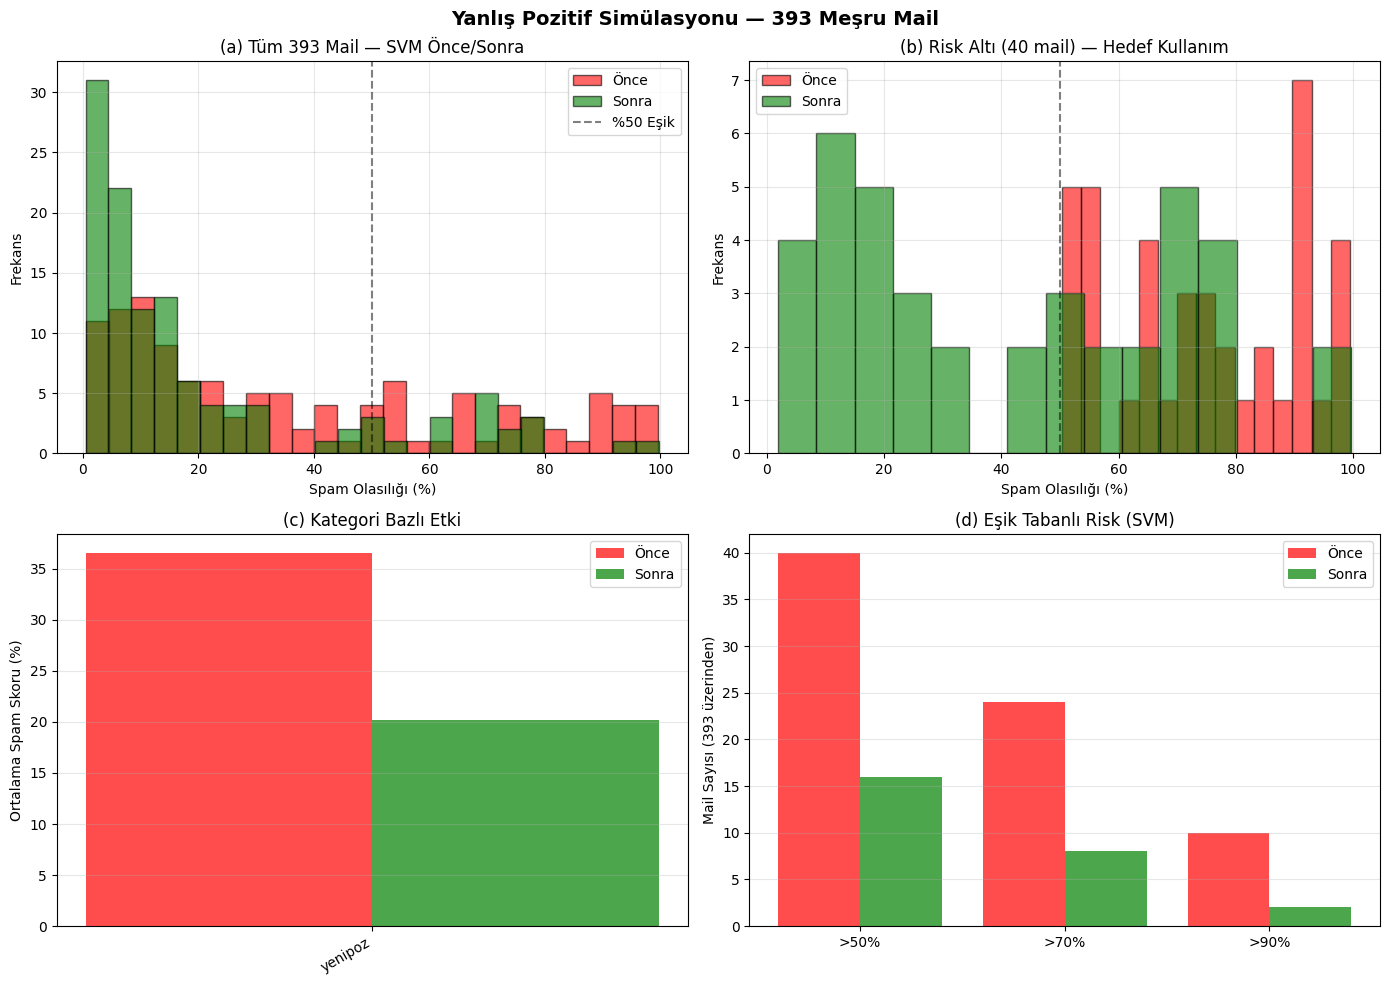


=== EN BÜYÜK 10 DÜŞÜŞ (SVM) ===

[1] Düşüş: 79.1 puan (91.9% → 12.8%)
    Kategori: yenipoz
    GİRDİ:    TRAFİK SİGORTANIZ GECİKTİ! BÜYÜK CEZA YİYECEKSİNİZ!!! RAY Sigorta poliçenizi yaptırmadan TRAFİĞE ÇIKMAYIN! Aracınız BAĞLANABİLİR, HEMEN teklif alın!
    YUMUŞAK:  Sayın müşterimiz, RAY Sigorta poliçenizin teslimatı sona ermiştir. Aracınızın güvenliğiniz için teklif almanızı rica ederiz.
    HEDEF:    Değerli müşterimiz, zorunlu trafik sigortası poliçenizin vadesi geçmiş bulunmaktadır. Yasal cezai müeyyidelerle karşılaşmamak ve aracınızın bağlanma riskini önlemek için Ray Sigorta'dan teklif alarak 

[2] Düşüş: 76.1 puan (92.1% → 16.0%)
    Kategori: yenipoz
    GİRDİ:    GÜVENCE BEDELİNİZ EKSİK KALDI! EPDK sisteminde güncellenen 450 TL tarife farkını hemen yatırmazsanız elektriğiniz KESİN OLARAK kesilecek!
    YUMUŞAK:  EPDK sisteminde güncellenen 450 TL tutarındaki tarife farkını yatırmanız gerekmektedir. Detaylar için e-posta adresini ziyaret edebilirsiniz.
    HEDEF:    Sayın ab

In [16]:
# 4 panelli grafik
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0,0]
ax.hist(yp_df['svm_before']*100, bins=25, alpha=0.6, color='red', label='Önce', edgecolor='black')
ax.hist(yp_df['svm_after']*100, bins=25, alpha=0.6, color='green', label='Sonra', edgecolor='black')
ax.axvline(x=50, color='black', linestyle='--', alpha=0.5, label='%50 Eşik')
ax.set_xlabel('Spam Olasılığı (%)'); ax.set_ylabel('Frekans')
ax.set_title('(a) Tüm 393 Mail — SVM Önce/Sonra')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[0,1]
risky_subset = yp_df[yp_df['svm_before'] > 0.5].copy()
ax.hist(risky_subset['svm_before']*100, bins=15, alpha=0.6, color='red', label='Önce', edgecolor='black')
ax.hist(risky_subset['svm_after']*100, bins=15, alpha=0.6, color='green', label='Sonra', edgecolor='black')
ax.axvline(x=50, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Spam Olasılığı (%)'); ax.set_ylabel('Frekans')
ax.set_title(f'(b) Risk Altı ({len(risky_subset)} mail) — Hedef Kullanım')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1,0]
kategoriler = sorted(yp_df['kategori'].unique())
bef_vals = [yp_df[yp_df['kategori']==k]['svm_before'].mean()*100 for k in kategoriler]
aft_vals = [yp_df[yp_df['kategori']==k]['svm_after'].mean()*100 for k in kategoriler]
x = np.arange(len(kategoriler))
ax.bar(x - 0.2, bef_vals, 0.4, label='Önce', color='red', alpha=0.7)
ax.bar(x + 0.2, aft_vals, 0.4, label='Sonra', color='green', alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(kategoriler, rotation=30, ha='right')
ax.set_ylabel('Ortalama Spam Skoru (%)')
ax.set_title('(c) Kategori Bazlı Etki')
ax.legend(); ax.grid(alpha=0.3, axis='y')

ax = axes[1,1]
thresholds = ['>50%', '>70%', '>90%']
b_vals = [(yp_df['svm_before']>0.5).sum(), (yp_df['svm_before']>0.7).sum(), (yp_df['svm_before']>0.9).sum()]
a_vals = [(yp_df['svm_after']>0.5).sum(), (yp_df['svm_after']>0.7).sum(), (yp_df['svm_after']>0.9).sum()]
x = np.arange(len(thresholds))
ax.bar(x - 0.2, b_vals, 0.4, label='Önce', color='red', alpha=0.7)
ax.bar(x + 0.2, a_vals, 0.4, label='Sonra', color='green', alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(thresholds)
ax.set_ylabel('Mail Sayısı (393 üzerinden)')
ax.set_title('(d) Eşik Tabanlı Risk (SVM)')
ax.legend(); ax.grid(alpha=0.3, axis='y')

plt.suptitle('Yanlış Pozitif Simülasyonu — 393 Meşru Mail', fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/yenipoz_results.png', dpi=150, bbox_inches='tight')
plt.show()

# En büyük 10 düşüş
yp_df['svm_drop'] = (yp_df['svm_before'] - yp_df['svm_after']) * 100
print("\n=== EN BÜYÜK 10 DÜŞÜŞ (SVM) ===")
top10 = yp_df.nlargest(10, 'svm_drop')
for i, (_, row) in enumerate(top10.iterrows(), 1):
    print(f"\n[{i}] Düşüş: {row['svm_drop']:.1f} puan ({row['svm_before']*100:.1f}% → {row['svm_after']*100:.1f}%)")
    print(f"    Kategori: {row['kategori']}")
    print(f"    GİRDİ:    {row['input']}")
    print(f"    YUMUŞAK:  {row['softened']}")
    print(f"    HEDEF:    {row['target_kurumsal']}")

top10.to_csv('/kaggle/working/yenipoz_top10.csv', index=False)

# Zor örnekler
hard_cases = yp_df[(yp_df['svm_before'] > 0.9) & (yp_df['svm_after'] > 0.7)]
print(f"\n=== ZOR ÖRNEKLER (>%90 önce, hâlâ >%70 sonra): {len(hard_cases)} ===")
for i, (_, row) in enumerate(hard_cases.head(5).iterrows(), 1):
    print(f"\n[{i}] {row['svm_before']*100:.1f}% → {row['svm_after']*100:.1f}%")
    print(f"    Kategori: {row['kategori']}")
    print(f"    GİRDİ:    {row['input']}")
    print(f"    YUMUŞAK:  {row['softened']}")

hard_cases.to_csv('/kaggle/working/yenipoz_hard.csv', index=False)
print("\n✓ TÜM ÇIKTILAR HAZIR")


In [17]:
# 1. BERTScore (Türkçe uyumlu)
!pip install -q bert-score

from bert_score import score as bert_score_fn

print("BERTScore hesaplanıyor (held-out 118 mail)...")
candidates = yp_df['softened'].tolist()
references = yp_df['target_kurumsal'].tolist()

# Türkçe için xlm-roberta veya distiluse kullan
P, R, F1 = bert_score_fn(
    candidates, references,
    model_type='dbmdz/bert-base-turkish-cased',
    num_layers=10,
    verbose=False
)

print(f"\nBERTScore (yumuşatılmış vs LLM-kurumsal hedef):")
print(f"  Precision (ort): {P.mean().item():.4f}")
print(f"  Recall (ort):    {R.mean().item():.4f}")
print(f"  F1 (ort):        {F1.mean().item():.4f}")

yp_df['bertscore_p'] = P.numpy()
yp_df['bertscore_r'] = R.numpy()
yp_df['bertscore_f1'] = F1.numpy()

# 2. Anahtar bilgi koruma oranı
import re

def extract_key_info(text):
    """Marka, URL, sayı bilgilerini çıkar"""
    if not isinstance(text, str):
        return {'brands': set(), 'urls': set(), 'numbers': set()}
    
    brands = set(find_brands_in_text(text).keys())
    urls = set([u.lower() for u in extract_urls(text)])
    numbers = set(re.findall(r'\b\d{2,}(?:[.,]\d+)?\b', text))
    
    return {'brands': brands, 'urls': urls, 'numbers': numbers}

print("\nAnahtar bilgi koruma analizi...")
brand_kept = []
url_kept = []
num_kept = []

for _, row in yp_df.iterrows():
    inp_info = extract_key_info(row['input'])
    out_info = extract_key_info(row['softened'])
    
    if inp_info['brands']:
        bk = len(inp_info['brands'] & out_info['brands']) / len(inp_info['brands'])
        brand_kept.append(bk)
    if inp_info['urls']:
        uk = len(inp_info['urls'] & out_info['urls']) / len(inp_info['urls'])
        url_kept.append(uk)
    if inp_info['numbers']:
        nk = len(inp_info['numbers'] & out_info['numbers']) / len(inp_info['numbers'])
        num_kept.append(nk)

import numpy as np
print(f"\n=== ANAHTAR BİLGİ KORUMA ORANI ===")
print(f"Marka koruma: %{np.mean(brand_kept)*100:.1f} (n={len(brand_kept)})")
print(f"URL koruma:   %{np.mean(url_kept)*100:.1f} (n={len(url_kept)})")
print(f"Sayı koruma:  %{np.mean(num_kept)*100:.1f} (n={len(num_kept)})")

# Kategori bazlı
print(f"\n=== KATEGORI BAZLI ===")
for kat in yp_df['kategori'].unique():
    sub = yp_df[yp_df['kategori']==kat]
    if len(sub) > 0:
        print(f"  {kat}: BERTScore F1={sub['bertscore_f1'].mean():.3f} (n={len(sub)})")

yp_df.to_csv('/kaggle/working/yenipoz_results_v4_full.csv', index=False)
print("\n✓ Tüm metrikler kaydedildi: yenipoz_results_v4_full.csv")


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.2 MB/s eta 0:00:00
BERTScore hesaplanıyor (held-out 118 mail)...


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]


BERTScore (yumuşatılmış vs LLM-kurumsal hedef):
  Precision (ort): 0.7237
  Recall (ort):    0.7078
  F1 (ort):        0.7146

Anahtar bilgi koruma analizi...

=== ANAHTAR BİLGİ KORUMA ORANI ===
Marka koruma: %100.0 (n=50)
URL koruma:   %91.4 (n=35)
Sayı koruma:  %93.8 (n=65)

=== KATEGORI BAZLI ===
  yenipoz: BERTScore F1=0.715 (n=118)

✓ Tüm metrikler kaydedildi: yenipoz_results_v4_full.csv


In [18]:
# 1. HuggingFace login
from huggingface_hub import login, HfApi, create_repo
 
# Token'ı Kaggle Secrets'tan al (önerilen)
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
HF_TOKEN = user_secrets.get_secret('HF_TOKEN')  # önce eklemen lazım
login(token=HF_TOKEN)
 
# 2. Repo oluştur
REPO_ID = 'HuseyinGH/mt5-tr-softener'  # kendi kullanıcı adınla değiştir
create_repo(REPO_ID, repo_type='model', private=False, exist_ok=True)
 
# 3. Modeli yükle
model.push_to_hub(REPO_ID)
tokenizer.push_to_hub(REPO_ID)
 
print(f'✓ Model yüklendi: https://huggingface.co/{REPO_ID}')


README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


✓ Model yüklendi: https://huggingface.co/HuseyinGH/mt5-tr-softener


In [21]:
# === SPAM CLASSIFIER'I HF'E YUKLE ===
# SVM modeli ve TF-IDF vectorizer zaten tez-spam-emails-tr
# dataset'inde hazir. Yeniden egitmiyoruz, sadece HF'e yukluyoruz.

import shutil, os
from huggingface_hub import HfApi, create_repo

# Dataset yolu (notebook'a input olarak ekli olmali)
SRC = '/kaggle/input/datasets/huseyinkaplan0/tez-spam-emails-tr'

# Calisma klasoru
os.makedirs('/kaggle/working/spam_clf', exist_ok=True)

# Hazir model dosyalarini kopyala (app.py'nin bekledigi adlarla)
shutil.copy(f'{SRC}/spam_classifier.pkl',
            '/kaggle/working/spam_clf/spam_svm.joblib')
shutil.copy(f'{SRC}/tfidf_vectorizer.pkl',
            '/kaggle/working/spam_clf/tfidf_vectorizer.joblib')

# Model card (README)
readme = '''---
language: tr
tags:
- spam-detection
- turkish
- scikit-learn
license: mit
---

# Turkish Spam Classifier (Linear SVM)

TF-IDF + CalibratedClassifierCV(LinearSVC, cv=3).
Test seti spam-sinifi F1: 0.9886

## Kullanim

```python
import joblib
svm = joblib.load('spam_svm.joblib')
vec = joblib.load('tfidf_vectorizer.joblib')
X = vec.transform(['ornek metin'])
prob = svm.predict_proba(X)[0, 1]
```
'''
with open('/kaggle/working/spam_clf/README.md', 'w') as f:
    f.write(readme)

# HF'e yukle
SPAM_REPO = 'HuseyinGH/turkish-spam-svm'
create_repo(SPAM_REPO, repo_type='model', private=False, exist_ok=True)

api = HfApi()
api.upload_folder(
    folder_path='/kaggle/working/spam_clf',
    repo_id=SPAM_REPO,
    repo_type='model'
)
print('Spam classifier yuklendi: https://huggingface.co/' + SPAM_REPO)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Spam classifier yuklendi: https://huggingface.co/HuseyinGH/turkish-spam-svm
